# P12: Transformer yordamida matnni umumlashtirish

Bu notebook Day 13 amaliyoti uchun. U PyTorch-first: vektorlar, attention, positional encoding va Transformer modeli `torch.Tensor` bilan ko'rsatiladi.

Bugungi amaliyotda capstone moduli avtomatik yozilmaydi. Oxirida `TransformerSummarizer` klassi tayyorlanadi; talabalar keyin uni capstone moduliga ko'chiradi.


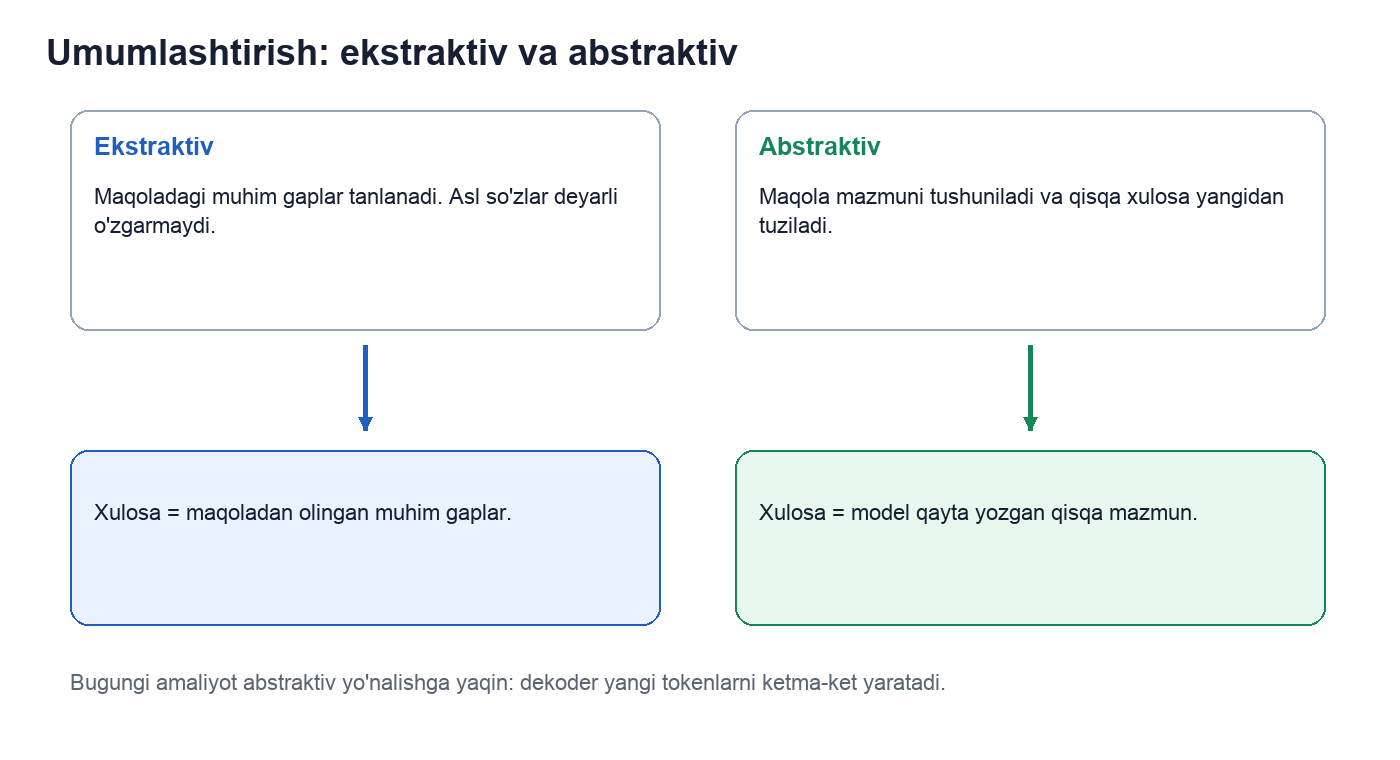


## 1. Muhit va dataset

Dataset 25 ta kichik o'zbekcha maqola va xulosa juftligidan iborat. Maqsad katta sifatli summarizer yasash emas, Transformer mexanikasini kichik, tez ishlaydigan tajribada ko'rish.

Kaggle'da `d13_checkpoints/uz_wiki_summ_mini.json` dataset sifatida ulangan bo'lsa, kod faylni avtomatik qidiradi.


In [33]:
from pathlib import Path
import json
import math
import random
import re
import sys

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("Device :", DEVICE)


Python : 3.12.13
PyTorch: 2.10.0+cu128
Device : cuda


In [34]:
DATA_FILE_NAME = "uz_wiki_summ_mini.json"

candidate_paths = [
    Path("practices/d13_checkpoints") / DATA_FILE_NAME,
    Path("d13_checkpoints") / DATA_FILE_NAME,
    Path(DATA_FILE_NAME),
]

if Path("/kaggle/input").exists():
    candidate_paths.extend(Path("/kaggle/input").rglob(DATA_FILE_NAME))

data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        f"{DATA_FILE_NAME} topilmadi. Kaggle'da d13_checkpoints papkasini dataset sifatida ulang."
    )

with open(data_path, encoding="utf-8") as file:
    pairs = json.load(file)

articles = [item["article"] for item in pairs]
summaries = [item["summary"] for item in pairs]

print("Dataset:", data_path)
print("Juftliklar soni:", len(pairs))
print("Maqola o'rtacha uzunligi:", round(sum(len(text.split()) for text in articles) / len(articles), 1), "so'z")
print("Xulosa o'rtacha uzunligi:", round(sum(len(text.split()) for text in summaries) / len(summaries), 1), "so'z")
print("\nMaqola namunasi:\n", articles[0])
print("\nXulosa namunasi:\n", summaries[0])


Dataset: /kaggle/input/datasets/khilolakhushmanova/d13-checkpoints/uz_wiki_summ_mini.json
Juftliklar soni: 25
Maqola o'rtacha uzunligi: 43.3 so'z
Xulosa o'rtacha uzunligi: 15.3 so'z

Maqola namunasi:
 O'zbekiston Markaziy Osiyoda joylashgan davlat bo'lib, shimolda Qozog'iston, sharqda Qirg'iziston va Tojikiston, janubda Afg'oniston, g'arbda Turkmaniston bilan chegaradosh. Mamlakat poytaxti va eng yirik shahri Toshkentdir. Aholisi 36 milliondan oshgan, bu ko'rsatkich bo'yicha Markaziy Osiyoda birinchi o'rinda turadi. Rasmiy tili o'zbek tili, pul birligi so'm hisoblanadi.

Xulosa namunasi:
 O'zbekiston Markaziy Osiyoda joylashgan davlat bo'lib, poytaxti Toshkent va aholisi 36 milliondan oshadi.


## 2. Tokenizatsiya va tensor batchlar

Transformer sonlar bilan ishlaydi. Shuning uchun har bir maqola tokenlarga bo'linadi, tokenlar id larga aylanadi, so'ng bir xil uzunlikka `PAD` bilan to'ldiriladi.


In [35]:
PAD_TOKEN = "<pad>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"
UNK_TOKEN = "<unk>"
SPECIAL_TOKENS = [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN, UNK_TOKEN]
PAD, BOS, EOS, UNK = range(4)


def tokenize(text):
    text = text.lower().replace("`", "'").replace("‘", "'").replace("’", "'")
    return re.findall(r"[a-zA-Z0-9']+", text)


def build_vocab(texts, min_freq=1):
    counts = {}
    for text in texts:
        for token in tokenize(text):
            counts[token] = counts.get(token, 0) + 1
    vocab = list(SPECIAL_TOKENS)
    vocab.extend(token for token, count in sorted(counts.items()) if count >= min_freq)
    token_to_id = {token: idx for idx, token in enumerate(vocab)}
    id_to_token = {idx: token for token, idx in token_to_id.items()}
    return token_to_id, id_to_token


def encode_text(text, token_to_id, max_length, add_bos=False, add_eos=True):
    ids = [token_to_id.get(token, UNK) for token in tokenize(text)]
    if add_bos:
        ids = [BOS] + ids
    if add_eos:
        ids = ids + [EOS]
    ids = ids[:max_length]
    if ids[-1] != EOS and add_eos:
        ids[-1] = EOS
    return ids


def pad_sequences(sequences, pad_id=PAD):
    max_len = max(len(seq) for seq in sequences)
    batch = torch.full((len(sequences), max_len), pad_id, dtype=torch.long)
    for row, seq in enumerate(sequences):
        batch[row, :len(seq)] = torch.tensor(seq, dtype=torch.long)
    return batch


def decode_ids(ids, id_to_token):
    words = []
    for idx in ids:
        idx = int(idx)
        if idx == EOS:
            break
        if idx in (PAD, BOS):
            continue
        words.append(id_to_token.get(idx, UNK_TOKEN))
    return " ".join(words)


In [36]:
src_token_to_id, src_id_to_token = build_vocab(articles)
tgt_token_to_id, tgt_id_to_token = build_vocab(summaries)

MAX_SRC_LEN = 64
MAX_TGT_LEN = 24

src_ids = [encode_text(text, src_token_to_id, MAX_SRC_LEN, add_bos=False, add_eos=True) for text in articles]
tgt_ids = [encode_text(text, tgt_token_to_id, MAX_TGT_LEN, add_bos=True, add_eos=True) for text in summaries]

src_batch = pad_sequences(src_ids).to(DEVICE)
tgt_batch = pad_sequences(tgt_ids).to(DEVICE)

decoder_input = tgt_batch[:, :-1]
target_output = tgt_batch[:, 1:]

print("src_batch:", tuple(src_batch.shape))
print("decoder_input:", tuple(decoder_input.shape))
print("target_output:", tuple(target_output.shape))
print("source vocab:", len(src_token_to_id), "target vocab:", len(tgt_token_to_id))


src_batch: (25, 57)
decoder_input: (25, 20)
target_output: (25, 20)
source vocab: 718 target vocab: 282


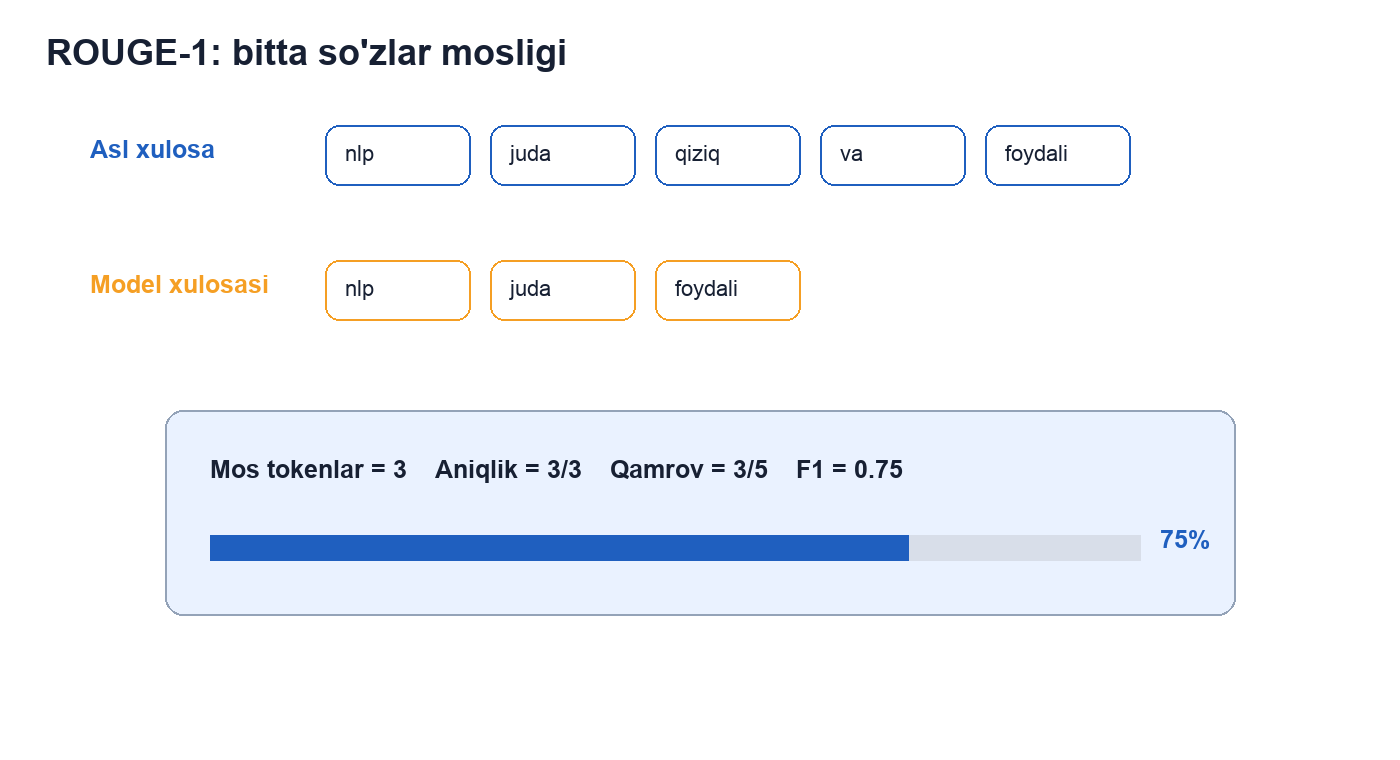


## 3. ROUGE-1: tezkor baholash

ROUGE-1 unigram overlapni o'lchaydi. Bu semantikani to'liq tushunmaydi, lekin kichik amaliyotda model chiqishini tez solishtirishga yordam beradi.


In [37]:
def rouge1_f1(reference, hypothesis):
    ref_tokens = tokenize(reference)
    hyp_tokens = tokenize(hypothesis)
    if not ref_tokens or not hyp_tokens:
        return 0.0

    ref_counts = {}
    for token in ref_tokens:
        ref_counts[token] = ref_counts.get(token, 0) + 1

    overlap = 0
    for token in hyp_tokens:
        if ref_counts.get(token, 0) > 0:
            overlap += 1
            ref_counts[token] -= 1

    precision = overlap / len(hyp_tokens)
    recall = overlap / len(ref_tokens)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)

reference = "nlp juda qiziq va foydali"
hypothesis = "nlp juda foydali"
print("ROUGE-1 F1:", round(rouge1_f1(reference, hypothesis), 3))


ROUGE-1 F1: 0.75


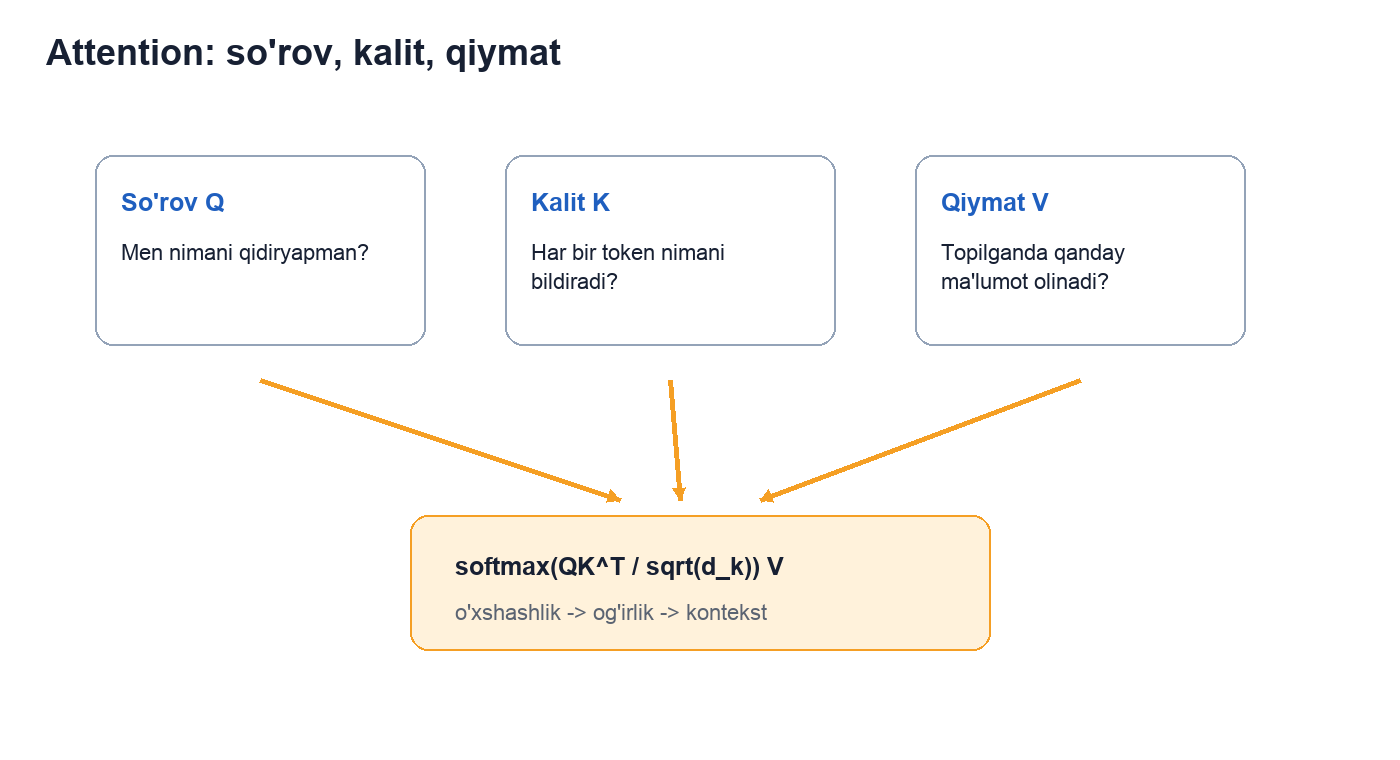


Q - so'rov
K - kalit
V - qiymat

## 4. Scaled dot-product attention

Attention savoli: hozirgi token boshqa tokenlardan qaysilariga ko'proq qarashi kerak? `Q @ K.T` o'xshashlik skorlarini beradi, `softmax` ularni og'irlikka aylantiradi, og'irliklar `V` qiymatlarining aralashmasini beradi.


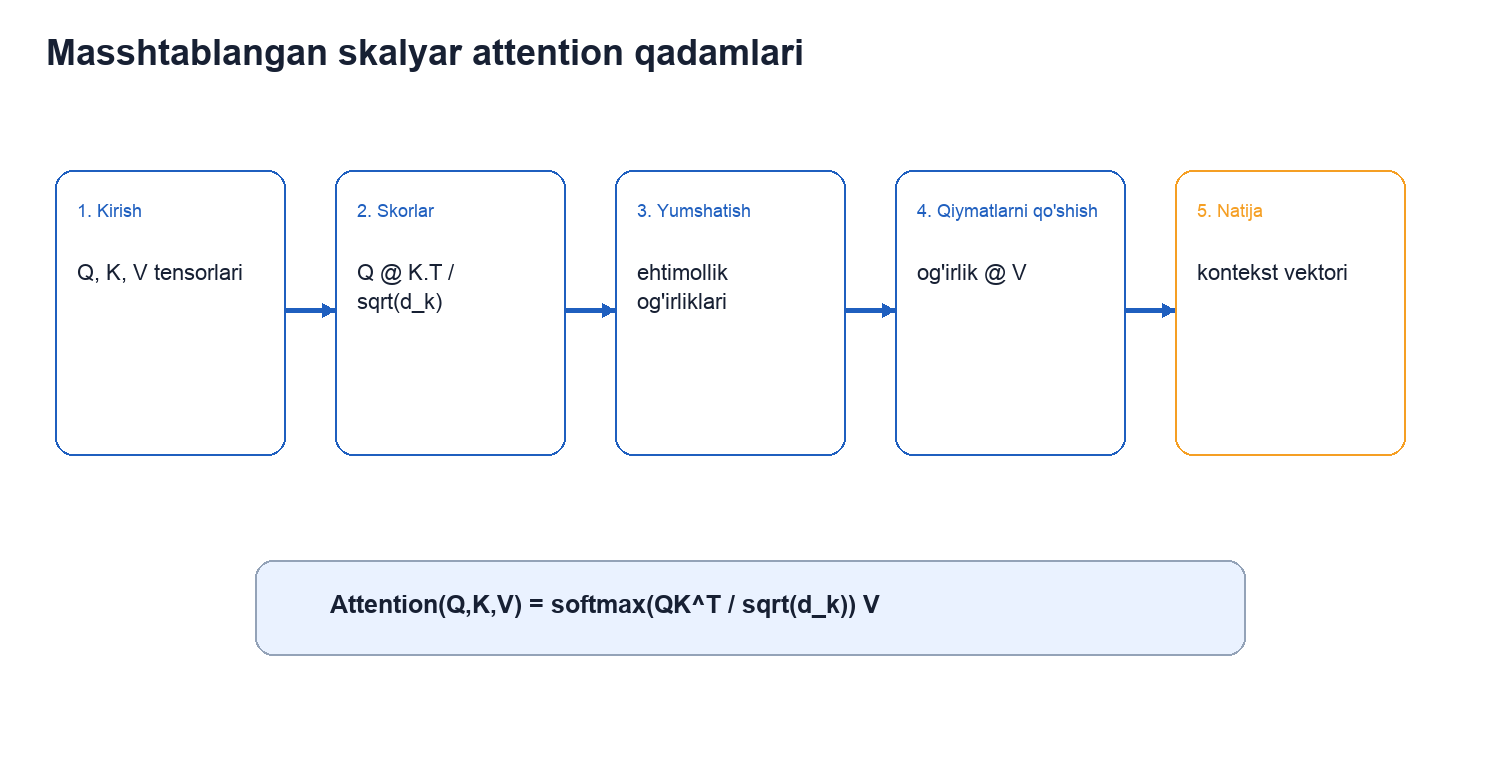


In [38]:
query = torch.tensor([[1.0, 0.0]], device=DEVICE)
keys = torch.tensor([[1.0, 0.0], [0.0, 1.0]], device=DEVICE)
values = torch.tensor([[10.0, 0.0], [0.0, 5.0]], device=DEVICE)

d_k = query.shape[-1]
scores = query @ keys.T / math.sqrt(d_k)
weights = torch.softmax(scores, dim=-1)
context = weights @ values

print("scores :", scores)
print("weights:", weights)
print("context:", context)


scores : tensor([[0.7071, 0.0000]], device='cuda:0')
weights: tensor([[0.6698, 0.3302]], device='cuda:0')
context: tensor([[6.6976, 1.6512]], device='cuda:0')


In [39]:
# SIZNING KODINGIZ:
query2 = torch.tensor([[0.0, 1.0]], device=DEVICE)
scores2 = query2 @ keys.T / math.sqrt(d_k)
weights2 = torch.softmax(scores2, dim=-1)
context2 = weights @ values
print(context2)


tensor([[6.6976, 1.6512]], device='cuda:0')


In [40]:
q = query.view(1, 1, 1, 2)
k = keys.view(1, 1, 2, 2)
v = values.view(1, 1, 2, 2)

context_from_api = F.scaled_dot_product_attention(q, k, v)
print(context_from_api.squeeze(0).squeeze(0))


tensor([[6.6976, 1.6512]], device='cuda:0')


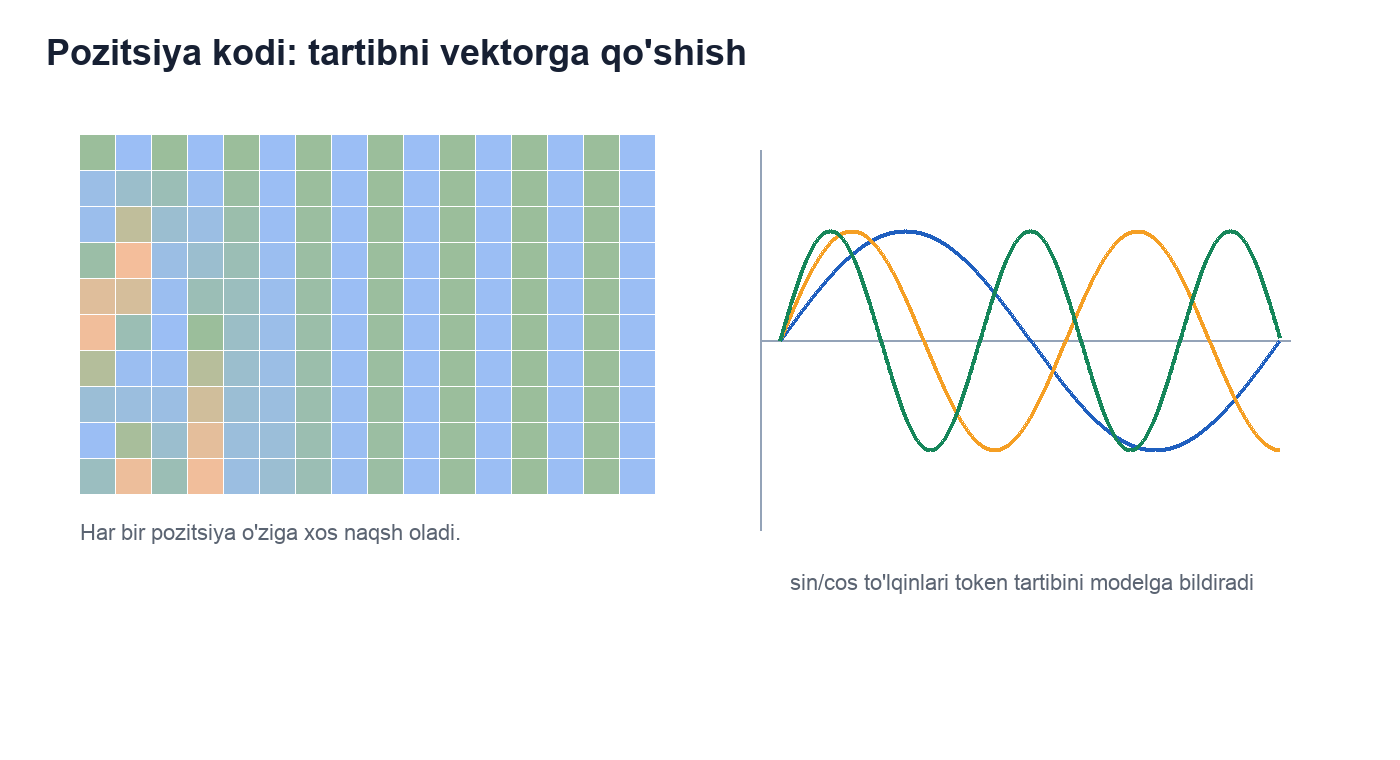


## 5. Positional encoding

Self-attention tokenlarni bir vaqtda ko'radi. Tartibni yo'qotmaslik uchun embeddingga pozitsiya signali qo'shiladi.


In [41]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=256):
        super().__init__()
        position = torch.arange(max_len, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2, dtype=torch.float32) * (-math.log(10000.0) / d_model))

        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, token_embeddings):
        seq_len = token_embeddings.size(1)
        return token_embeddings + self.pe[:, :seq_len]

pe = PositionalEncoding(d_model=8, max_len=6).to(DEVICE)
dummy_embeddings = torch.zeros(1, 6, 8, device=DEVICE)
print(pe(dummy_embeddings)[0, :3])


tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9833e-02,  9.9500e-01,  9.9998e-03,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9867e-01,  9.8007e-01,  1.9999e-02,
          9.9980e-01,  2.0000e-03,  1.0000e+00]], device='cuda:0')


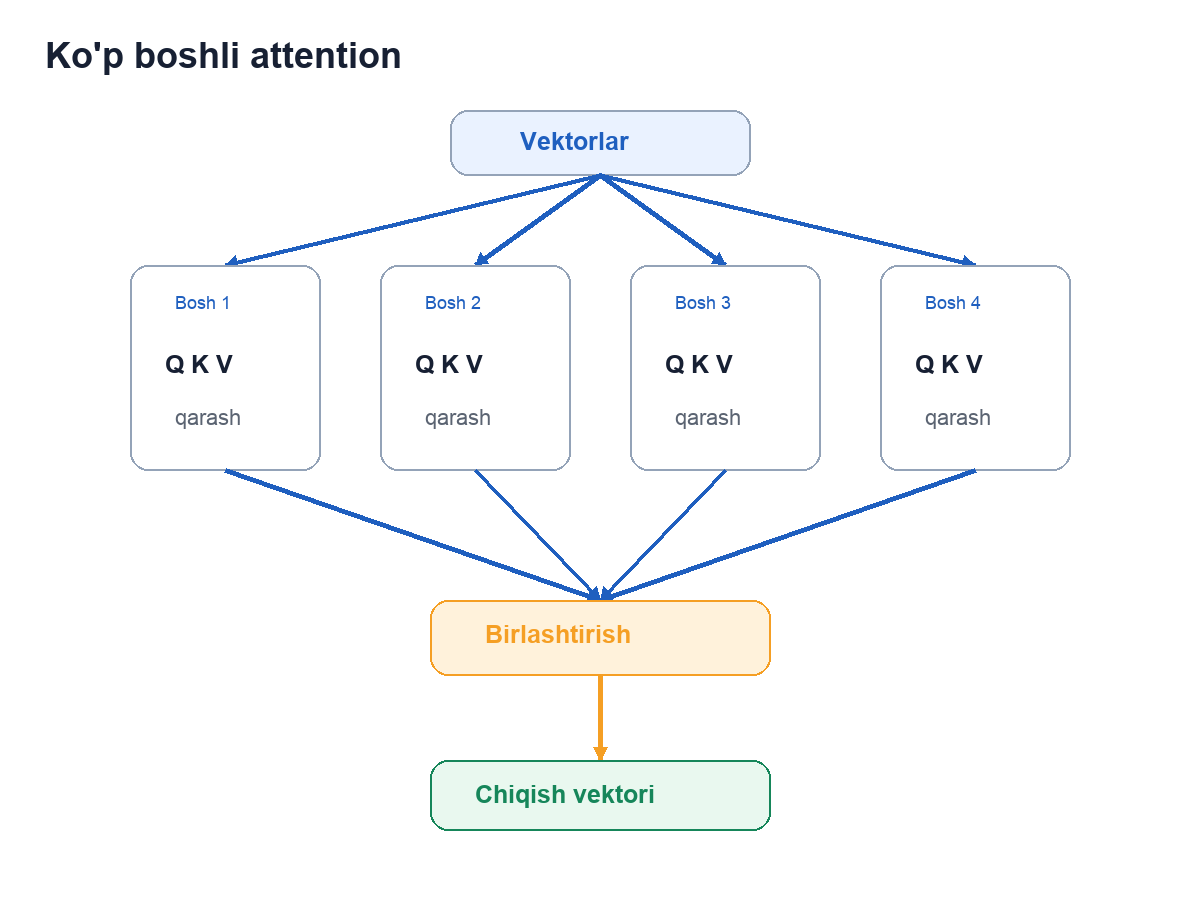


## 6. Multi-head attention

Bitta attention boshi bitta turdagi aloqani ko'rishi mumkin. Bir nechta boshlar turli munosabatlarni parallel ko'radi, keyin natijalar birlashtiriladi.


In [42]:
embed_dim = 8
num_heads = 2
multihead_attention = nn.MultiheadAttention(embed_dim=embed_dim, num_heads=num_heads, batch_first=True).to(DEVICE)

x = torch.randn(1, 4, embed_dim, device=DEVICE)
attn_output, attn_weights = multihead_attention(x, x, x, need_weights=True)

print("input       :", tuple(x.shape))
print("attn_output :", tuple(attn_output.shape))
print("attn_weights:", tuple(attn_weights.shape))


input       : (1, 4, 8)
attn_output : (1, 4, 8)
attn_weights: (1, 4, 4)


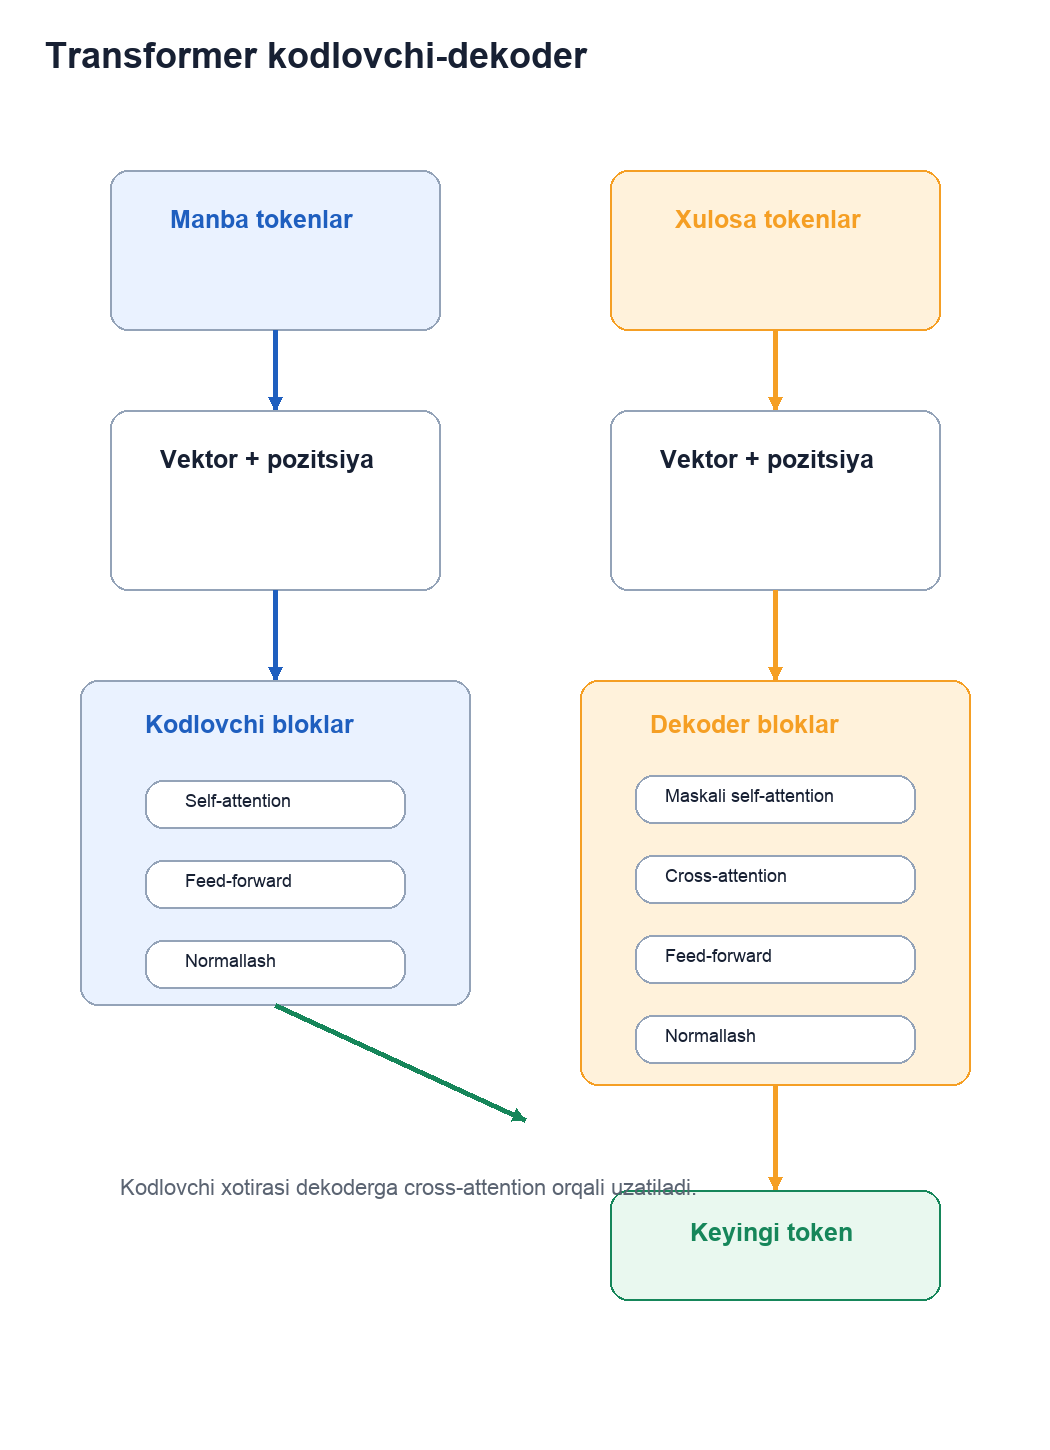


## 7. Mini Transformer summarizer

Encoder maqolani kontekst vektorlariga aylantiradi. Decoder esa oldingi xulosa tokenlariga va encoder xotirasiga qarab keyingi tokenni yaratadi.


In [43]:
class TinyTransformerSummarizer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.src_embedding = nn.Embedding(src_vocab_size, d_model, padding_idx=PAD)
        self.tgt_embedding = nn.Embedding(tgt_vocab_size, d_model, padding_idx=PAD)
        self.positional_encoding = PositionalEncoding(d_model)
        self.transformer = nn.Transformer(
            d_model=d_model,
            nhead=nhead,
            num_encoder_layers=num_layers,
            num_decoder_layers=num_layers,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )
        self.output_layer = nn.Linear(d_model, tgt_vocab_size)

    def forward(self, src, tgt_input):
        tgt_len = tgt_input.size(1)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(tgt_len).to(tgt_input.device)
        src_padding_mask = src.eq(PAD)
        tgt_padding_mask = tgt_input.eq(PAD)

        src_emb = self.positional_encoding(self.src_embedding(src) * math.sqrt(self.d_model))
        tgt_emb = self.positional_encoding(self.tgt_embedding(tgt_input) * math.sqrt(self.d_model))

        hidden = self.transformer(
            src=src_emb,
            tgt=tgt_emb,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_padding_mask,
            tgt_key_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )
        return self.output_layer(hidden)


## 8. O'qitish

Kichik dataset sabab model tez overfit qiladi. Bu yerda maqsad production sifat emas, balki forward pass, loss, gradient va decoding oqimini ko'rish.


In [44]:
model = TinyTransformerSummarizer(
    src_vocab_size=len(src_token_to_id),
    tgt_vocab_size=len(tgt_token_to_id),
).to(DEVICE)

loss_fn = nn.CrossEntropyLoss(ignore_index=PAD)
optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

EPOCHS = 600

# SIZNING KODINGIZ:
for epoch in range(1, EPOCHS+1):
    model.train()
    optimizer.zero_grad()
    logits = model(src_batch, decoder_input)
    loss = loss_fn(
        logits.reshape(-1, logits.size(-1)),
        target_output.reshape(-1)
    )
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm = 1.0)
    optimizer.step()
    if epoch == 1 or epoch%15==0:
        print(f"epoch{epoch:03d}| loss {loss.item():.4f}")
    


# 3. loss ni logits va target_output orqali hisoblang
# 4. backward, step, zero_grad qadamlarini bajaring
# 5. har 15 epochda loss ni chiqaring


epoch001| loss 5.8087
epoch015| loss 3.4167
epoch030| loss 1.5589
epoch045| loss 0.5091
epoch060| loss 0.1771
epoch075| loss 0.0863
epoch090| loss 0.0502
epoch105| loss 0.0352
epoch120| loss 0.0259
epoch135| loss 0.0220
epoch150| loss 0.0194
epoch165| loss 0.0164
epoch180| loss 0.0144
epoch195| loss 0.0122
epoch210| loss 0.0120
epoch225| loss 0.0100
epoch240| loss 0.0085
epoch255| loss 0.0074
epoch270| loss 0.0067
epoch285| loss 0.0062
epoch300| loss 0.0057
epoch315| loss 0.0055
epoch330| loss 0.0052
epoch345| loss 0.0040
epoch360| loss 0.0044
epoch375| loss 0.0040
epoch390| loss 0.0036
epoch405| loss 0.0049
epoch420| loss 0.0035
epoch435| loss 0.0033
epoch450| loss 0.0030
epoch465| loss 0.0028
epoch480| loss 0.0029
epoch495| loss 0.0035
epoch510| loss 0.0032
epoch525| loss 0.0026
epoch540| loss 0.0029
epoch555| loss 0.0028
epoch570| loss 0.0026
epoch585| loss 0.0022
epoch600| loss 0.0020


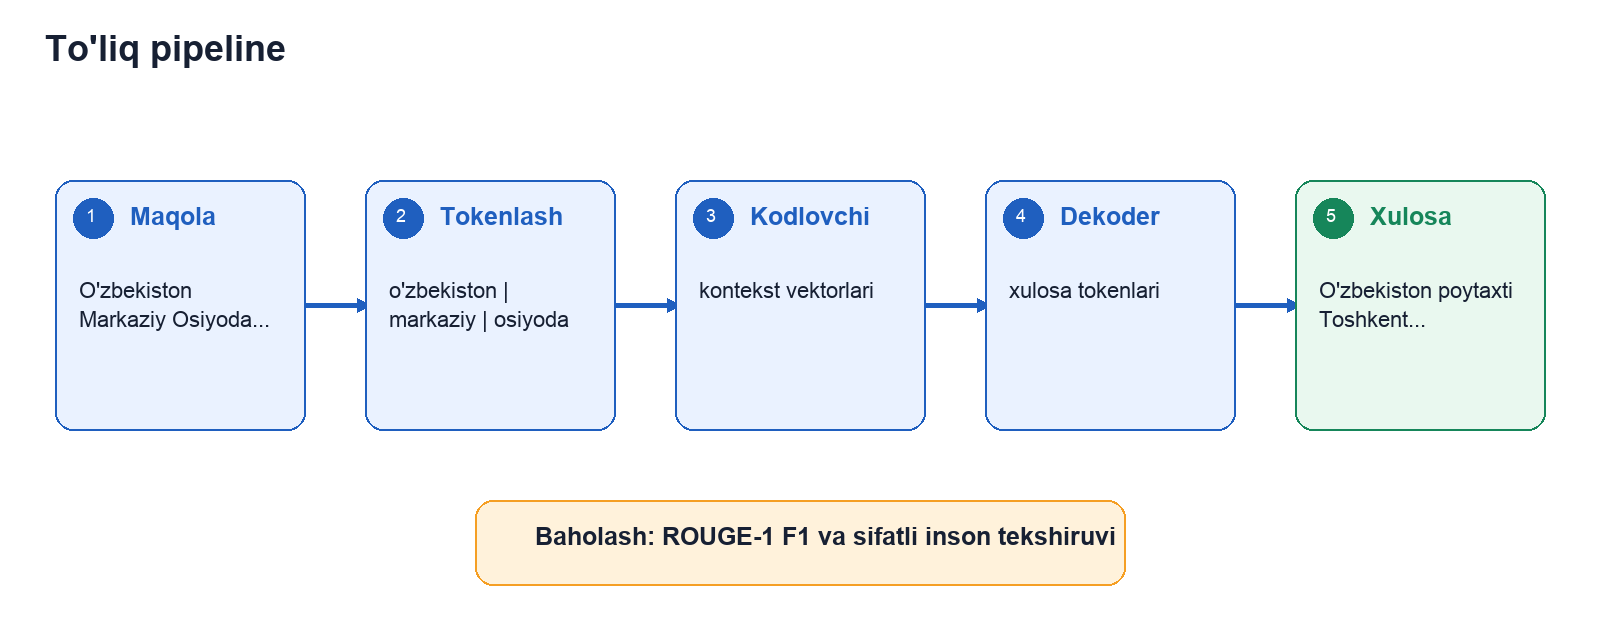


## 9. Greedy decoding va natijani tekshirish

Decoder avval `<bos>` bilan boshlaydi. Har qadamda eng katta ehtimolli token olinadi va keyingi qadamga kirish sifatida beriladi.


In [45]:
def greedy_summarize(model, text, max_length=20):
    model.eval()
    src = pad_sequences([encode_text(text, src_token_to_id, MAX_SRC_LEN, add_bos=False, add_eos=True)]).to(DEVICE)
    generated = torch.tensor([[BOS]], dtype=torch.long, device=DEVICE)

    with torch.no_grad():
        for _ in range(max_length):
            logits = model(src, generated)
            next_id = logits[:, -1].argmax(dim=-1, keepdim=True)
            generated = torch.cat([generated, next_id], dim=1)
            if int(next_id.item()) == EOS:
                break

    return decode_ids(generated[0].tolist(), tgt_id_to_token)


In [46]:
# Modelni o'qitgandan keyin ushbu cellni ishlating.
# SIZNING KODINGIZ:
scores = []
for article, gold_summary in list(zip(articles, summaries))[:5]:
    predicted_summary = greedy_summarize(model, article)
    score = rouge1_f1(gold_summary, predicted_summary)
    scores.append(score)
    print("GOLD:", gold_summary)
    print("PRED:", predicted_summary)
    print("ROUGE-1:", rouge1_f1(gold_summary, predicted_summary))
print("O'rtacha ROUGE-1 F1: ", round(sum(scores)/len(scores), 3))

GOLD: O'zbekiston Markaziy Osiyoda joylashgan davlat bo'lib, poytaxti Toshkent va aholisi 36 milliondan oshadi.
PRED: o'zbekiston markaziy osiyoda joylashgan davlat bo'lib poytaxti toshkent va aholisi 36 milliondan oshadi
ROUGE-1: 1.0
GOLD: Toshkent O'zbekistonning poytaxti bo'lib, Chirchiq daryosi vodiyida joylashgan va 2000 yillik tarixga ega.
PRED: toshkent o'zbekistonning poytaxti bo'lib chirchiq daryosi vodiyida joylashgan va 2000 yillik tarixga ega
ROUGE-1: 1.0
GOLD: Samarqand Zarafshon vodiysida joylashgan qadimiy shahar bo'lib, Temuriylar poytaxti va ipak yo'lining muhim markazi bo'lgan.
PRED: samarqand zarafshon vodiysida joylashgan qadimiy shahar bo'lib temuriylar poytaxti va ipak yo'lining muhim markazi bo'lgan
ROUGE-1: 1.0
GOLD: Mirzo Ulug'bek o'zbek astronomi bo'lib, Samarqandda rasadxona qurgan va 1018 ta yulduz koordinatalarini aniqlagan.
PRED: mirzo ulug'bek o'zbek astronomi bo'lib samarqandda rasadxona qurgan va 1018 ta yulduz koordinatalarini aniqlagan
ROUGE-1: 1.0
GO

## 10. Capstone chiqishi: `TransformerSummarizer`

Bu klass bugungi amaliyotning yakuniy mahsuloti. Talabalar uni keyin capstone moduliga ko'chiradi. Notebookning o'zi hech qanday `.py` fayl yozmaydi.


In [50]:
class TransformerSummarizer:
    """Amaliyot oxirida capstone moduliga ko'chiriladigan sodda wrapper."""

    def __init__(self, max_src_len=64, max_tgt_len=24, device=None):
        self.max_src_len = max_src_len
        self.max_tgt_len = max_tgt_len
        self.device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model = None
        self.src_token_to_id = None
        self.src_id_to_token = None
        self.tgt_token_to_id = None
        self.tgt_id_to_token = None

    def fit(self, articles, summaries, epochs=60, lr=0.003):
        # Vocabulary
        self.src_token_to_id, self.src_id_to_token = build_vocab(articles)
        self.tgt_token_to_id, self.tgt_id_to_token = build_vocab(summaries)
    
        # Encode
        src_sequences = [
            encode_text(
                article,
                self.src_token_to_id,
                self.max_src_len,
                add_bos=False,
                add_eos=True,
            )
            for article in articles
        ]
    
        tgt_sequences = [
            encode_text(
                summary,
                self.tgt_token_to_id,
                self.max_tgt_len,
                add_bos=True,
                add_eos=True,
            )
            for summary in summaries
        ]
    
        # Batch
        src_batch = pad_sequences(src_sequences).to(self.device)
        tgt_batch = pad_sequences(tgt_sequences).to(self.device)
    
        decoder_input = tgt_batch[:, :-1]
        target_output = tgt_batch[:, 1:]
    
        # Model
        self.model = TinyTransformerSummarizer(
            src_vocab_size=len(self.src_token_to_id),
            tgt_vocab_size=len(self.tgt_token_to_id),
        ).to(self.device)
    
        optimizer = torch.optim.Adam(self.model.parameters(), lr=lr)
    
        loss_fn = nn.CrossEntropyLoss(ignore_index=PAD)
        # Training
        for epoch in range(1, epochs + 1):
    
            self.model.train()
    
            optimizer.zero_grad()
    
            logits = self.model(src_batch, decoder_input)
    
            loss = loss_fn(
                logits.reshape(-1, logits.size(-1)),
                target_output.reshape(-1)
            )
    
            loss.backward()
    
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
    
            optimizer.step()
    
            if epoch == 1 or epoch % 15 == 0:
                print(f"Epoch {epoch:03d} | Loss = {loss.item():.4f}")
        return self

    def summarize(self, text, max_length=20):
        self.model.eval()

        with torch.no_grad():
    
            # Source matnni encode qilish
            src = encode_text(
                text,
                self.src_token_to_id,
                self.max_src_len,
                add_bos=False,
                add_eos=True,
            )
    
            src = pad_sequences([src]).to(self.device)
    
            # Decoder <bos> bilan boshlanadi
            generated = [BOS]
    
            for _ in range(max_length):
    
                decoder_input = torch.tensor(
                    [generated],
                    dtype=torch.long,
                    device=self.device,
                )
    
                logits = self.model(src, decoder_input)
    
                # Oxirgi token uchun eng katta ehtimollikni tanlash
                next_token = logits[:, -1, :].argmax(dim=-1).item()
    
                if next_token == EOS:
                    break
    
                generated.append(next_token)

        return decode_ids(generated, self.tgt_id_to_token)

    def score(self, articles, summaries):
        scores = []

        for article, summary in zip(articles, summaries):
            prediction = self.summarize(article)
            scores.append(rouge1_f1(prediction, summary))
    
        return sum(scores) / len(scores)
            
print('tugadi')

tugadi


## Chiqish savoli

1. Nima uchun decoderda mask kerak?
2. ROUGE-1 qaysi holatda adashishi mumkin?
3. Positional encoding bo'lmasa, self-attention nimani yo'qotadi?


Decoder kelajakdagi so'zlarni ko'rmasligi uchun, faqat oldingi so'zlarga qarab keyingi so'zni bashorat qiladi.
Ma'nosi bir xil, lekin boshqa so'zlar bilan yozilgan matnlarni past baholashi mumkin.
So'zlarning tartibi (ketma-ketligi) haqidagi ma'lumotni yo'qotadi.